# Import modules 

In [31]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from PlotClassification import plot_decision_regions
from sklearn import tree 
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split


# Generate random data

In [32]:
def getDataset():
    np.random.seed(1)
    X_xor = np.random.rand(1000, 2)
    y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0)
    y_xor = np.where(y_xor, 1, -1)
    return X_xor, y_xor

# Begin training

[Text(0.6237342359050445, 0.9761904761904762, 'x[1] <= 0.809\ngini = 0.5\nsamples = 700\nvalue = [361, 339]'),
 Text(0.41556936201780414, 0.9285714285714286, 'x[0] <= 0.972\ngini = 0.495\nsamples = 554\nvalue = [305, 249]'),
 Text(0.28874258160237387, 0.8809523809523809, 'x[1] <= 0.007\ngini = 0.493\nsamples = 537\nvalue = [301, 236]'),
 Text(0.2839948071216617, 0.8333333333333334, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.29349035608308605, 0.8333333333333334, 'x[0] <= 0.26\ngini = 0.492\nsamples = 533\nvalue = [301, 232]'),
 Text(0.06832344213649852, 0.7857142857142857, 'x[0] <= 0.25\ngini = 0.463\nsamples = 154\nvalue = [98, 56]'),
 Text(0.03397626112759644, 0.7380952380952381, 'x[0] <= 0.024\ngini = 0.472\nsamples = 144\nvalue = [89, 55]'),
 Text(0.009495548961424332, 0.6904761904761905, 'x[0] <= 0.001\ngini = 0.278\nsamples = 12\nvalue = [10, 2]'),
 Text(0.004747774480712166, 0.6428571428571429, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.014243323442136498, 0.64

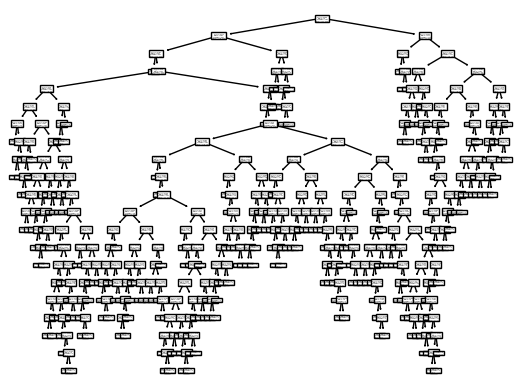

In [33]:
X, Y = getDataset()
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 1)

# Check if there's only one unique class in the training data
if len(np.unique(y_train)) == 1:
    # Introduce some noise to ensure both classes are represented
    noise = np.random.randint(0, 2, size=len(y_train))  # Random noise: 0 or 1
    y_train = np.where(y_train == 1, 1, -1) * (2 * noise - 1)  # Flip the sign of some samples

# Create classification 
tree_clf = DecisionTreeClassifier(max_depth=20)
tree_clf.fit(X_train, y_train)

# Display trained tree 
tree.plot_tree(tree_clf)


# Plot Results

c:\Users\pc\Documents\AI_Learning\HomeWork\DT_RF\PlotClassification.py:24: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


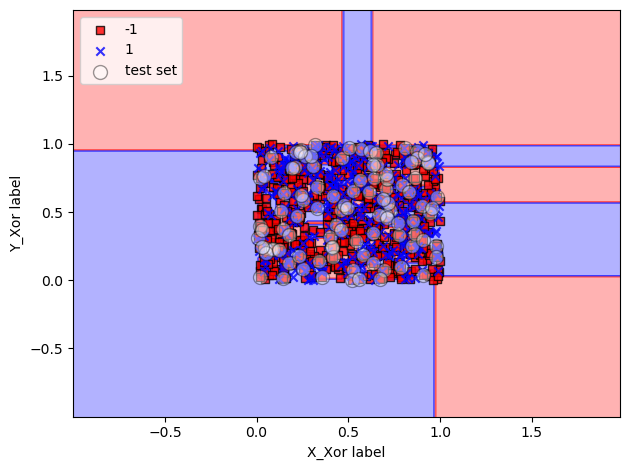

0.848

In [34]:
X_combined = np.vstack((X_train, X_test))
Y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X_combined, Y_combined, classifier=tree_clf, test_idx=range(900, 1000))
plt.xlabel('X_Xor label')
plt.ylabel('Y_Xor label')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()  
tree_clf.score(X_combined, Y_combined)

# Print Confusion Matrix

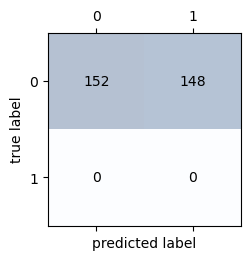

In [35]:
y_test_pred=tree_clf.predict(X_test)
accuracy_score(y_test, y_test_pred)
confmat = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')
plt.xlabel('predicted label')
plt.ylabel('true label')
plt.show()